In [241]:
%matplotlib widget
import csv
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from dataclasses import dataclass

# ============================================================
# 1. STYLE & OBJECT CONFIGURATION
# ============================================================
@dataclass
class Spectrum:
    N: str                  # Nombre o Label original
    X: np.ndarray           # X data
    Y: np.ndarray           # Y data
    wcorr: float = 0.0          # Factor de corrección de agua por defecto
    color: str = None       # Color para ploteo
    linestyle: str = None   # Estilo de línea
    a: float = 0.0          # Parámetro a opcional para fondo
    b: float = 0.0          # Parámetro b opcional para fondo

    def copy(self):
        return Spectrum(
            N=self.N, 
            X=self.X.copy(), 
            Y=self.Y.copy(), 
            wcorr= self.wcorr,
            color=self.color,         
            linestyle=self.linestyle,
            a=self.a,
            b=self.b
        )
poster_style = {
    "figsize": (5, 4),          
    "dpi": 300,                 
    "font_size": 12,
    "title_size": 14,
    "label_size": 14,
    "legend_size": 10,
    "line_width": 1.5,
    "font_family": "Calibri", 
    "grid": True,               
    "colors": ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

# ============================================================
# 2. UV-VIS PLOTTING ENGINE (With Energy Axis Support)
# ============================================================
def PlotSpectra(spectra_list, mode="WE", style=poster_style, 
                xlabel_W="Wavelength (nm)", xlabel_E="Energy (eV)", ylabel="Optical Density (a.u.)", title="Optical Density (a.u.)", 
                xmin=None, xmax=None, ymin=None, ymax=None, 
                offset_step=0.0, hide_yticks=False, save_path=None):
    
    fig, ax1 = plt.subplots(figsize=style["figsize"], dpi=style["dpi"])
    plt.rcParams.update({"font.size": style["font_size"], "font.family": style["font_family"]})
    
    default_colors = style.get("colors") or ["#000000"]
    default_linestyles = style.get("linestyles") or ["-"]
    
    for i, s in enumerate(spectra_list):
        c = getattr(s, 'color', None) or default_colors[i % len(default_colors)]
        ls = getattr(s, 'linestyle', None) or default_linestyles[i % len(default_linestyles)]
        y_stacked = s.Y + (i * offset_step)
        
        if mode in ["W", "WE"]:
            ax1.plot(s.X, y_stacked, label=s.N, linewidth=style["line_width"], color=c, linestyle=ls)
            ax1.set_xlabel(xlabel_W, fontsize=style["label_size"])
        elif mode in ["E", "EW"]:
            E_array = np.divide(1240.0, s.X, out=np.zeros_like(s.X), where=s.X != 0)
            ax1.plot(E_array, y_stacked, label=s.N, linewidth=style["line_width"], color=c, linestyle=ls)
            ax1.set_xlabel(xlabel_E, fontsize=style["label_size"])

    ax1.set_ylabel(ylabel, fontsize=style["label_size"])
    
    if hide_yticks:
        ax1.set_yticklabels([])

    #ax1.set_title(title, fontsize=style["title_size"])
    
    if xmin is not None or xmax is not None: ax1.set_xlim(xmin, xmax)
    if ymin is not None or ymax is not None: ax1.set_ylim(ymin, ymax)
    if style.get("grid", False): ax1.grid(True, alpha=0.3)

    # --- Ejes Secundarios (Energía <-> Wavelength) ---
    if mode in ["WE", "EW"]:
        def forward(x):
            with np.errstate(divide='ignore', invalid='ignore'):
                return np.where(x == 0, np.inf, 1240.0 / x)
        def inverse(x):
            with np.errstate(divide='ignore', invalid='ignore'):
                return np.where(x == 0, np.inf, 1240.0 / x)

        if mode == "WE":
            ax2 = ax1.secondary_xaxis('top', functions=(forward, inverse))
            ax2.set_xlabel(xlabel_E, fontsize=style["label_size"])
        elif mode == "EW":
            ax2 = ax1.secondary_xaxis('top', functions=(inverse, forward))
            ax2.set_xlabel(xlabel_W, fontsize=style["label_size"])

    ax1.legend(fontsize=style["legend_size"], ncol=1,frameon=False)
    fig.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=style["dpi"], bbox_inches="tight")
        print(f"Saved: {save_path}")
        
    plt.show()

    
def ApplyWaterCorrection(spectra_list, calibration_obj):
    """
    Aplica la corrección de agua usando s.wcorr definido en cada espectro.
    """
    res = []
    for s in spectra_list:
        new_s = s.copy()
        cal_interp = np.interp(new_s.X, calibration_obj.X, calibration_obj.Y)
        new_s.Y = new_s.Y - (new_s.wcorr * cal_interp)
        res.append(new_s)
    return res
def ApplyNZCorrection(spectra_list, calibration_obj):
    """
    Aplica la corrección de agua usando s.wcorr definido en cada espectro.
    """
    res = []
    for s in spectra_list:
        new_s = s.copy()
        cal_interp = np.interp(new_s.X, calibration_obj.X, calibration_obj.Y)
        new_s.Y = new_s.Y - (new_s.nzcorr * cal_interp)
        res.append(new_s)
    return res

def TrimSpectra(spectra_input, xmin=None, xmax=None):
    if not isinstance(spectra_input, list):
        spectra_input = [spectra_input]
    res = []
    for s in spectra_input:
        new_s = s.copy()
        mask = np.ones_like(new_s.X, dtype=bool)
        if xmin is not None: mask &= (new_s.X >= xmin)
        if xmax is not None: mask &= (new_s.X <= xmax)
        
        if not np.any(mask):
            print(f"Warning: empty trim range for {new_s.N}")
            continue
            
        new_s.X = new_s.X[mask]
        new_s.Y = new_s.Y[mask]
        res.append(new_s)
    return res

def NormalizeSpectra(spectra_list, xmin, xmax, mode="M"):
    """
    mode="M" (Maximum), "I" (Integration/Area), "V" (Minimum)
    """
    res = []
    for s in spectra_list:
        new_s = s.copy()
        # Encontrar datos dentro de la ventana
        mask = (new_s.X >= xmin) & (new_s.X <= xmax)
        X_win, Y_win = new_s.X[mask], new_s.Y[mask]
        
        if len(X_win) == 0: 
            print(f"Warning: No data in normalization window for {new_s.N}")
            continue
        
        if mode.upper() == "M": factor = np.max(Y_win)
        elif mode.upper() == "I": factor = np.trapezoid(Y_win, X_win)
        elif mode.upper() == "V": factor = np.min(Y_win)
        else: raise ValueError("Invalid mode")
        
        if factor != 0:
            new_s.Y = new_s.Y / factor
        res.append(new_s)
    return res

def SubtractMinimum(spectra_input, xmin=None, xmax=None):
    """
    Encuentra el mínimo en la región [xmin, xmax] y se lo resta a todo el espectro.
    Esto 'arrastra' el espectro hacia abajo para que el mínimo local sea exactamente cero.
    """
    is_single = isinstance(spectra_input, Spectrum)
    spectra_list = [spectra_input] if is_single else spectra_input
    
    res = []
    for s in spectra_list:
        new_s = s.copy()
        
        # Encontrar la ventana para buscar el mínimo
        mask = np.ones_like(new_s.X, dtype=bool)
        if xmin is not None: mask &= (new_s.X >= xmin)
        if xmax is not None: mask &= (new_s.X <= xmax)
        
        if not np.any(mask):
            print(f"Warning: Rango de búsqueda de mínimo vacío para {new_s.N}")
            res.append(new_s)
            continue
            
        # Buscar el valor Y más bajo en esa ventana y restarlo a todo el array
        min_val = np.min(new_s.Y[mask])
        new_s.Y = new_s.Y - min_val
        
        res.append(new_s)
        
    return res[0] if is_single else res

def SubtractLinearBackground(spectra_input, x1, x2):
    """
    Evalúa la intensidad en x1 y x2, traza una línea recta entre ellos 
    (y = mx + b) y la resta de todo el espectro para eliminar fondos inclinados.
    """
    is_single = isinstance(spectra_input, Spectrum)
    spectra_list = [spectra_input] if is_single else spectra_input
    
    res = []
    for s in spectra_list:
        new_s = s.copy()
        
        if x1 == x2:
            print(f"Warning: x1 y x2 son idénticos para {new_s.N}. No se aplicó baseline.")
            res.append(new_s)
            continue
            
        # Interpolar para asegurar que obtenemos el valor Y exacto en x1 y x2 
        # (incluso si el punto X exacto no existe en el array original)
        y1 = np.interp(x1, new_s.X, new_s.Y)
        y2 = np.interp(x2, new_s.X, new_s.Y)
        
        # Calcular pendiente (m) y punto de corte (b)
        m = (y2 - y1) / (x2 - x1)
        b = y1 - m * x1
        
        # Calcular la recta para todo el eje X y restarla
        line_y = m * new_s.X + b
        new_s.Y = new_s.Y - line_y
        
        res.append(new_s)
        
    return res[0] if is_single else res

def BackgroundCorrection(spectra_list):
    """Aplica la corrección de fondo usando los atributos .a y .b de cada espectro."""
    res = []
    for s in spectra_list:
        new_s = s.copy()
        # Calculamos el fondo de forma segura evitando divisiones por cero en X
        with np.errstate(divide='ignore', invalid='ignore'):
            bg = np.where(new_s.X == 0, 0.0, (new_s.a / new_s.X) + new_s.b)
        new_s.Y = new_s.Y - bg
        res.append(new_s)
    return res

# ============================================================
# 3. ABSORPTION CSV LOADER (ROBUST VERSION)
# ============================================================
def read_absorption_csv(filename):
    samples = {}
    with open(filename, "r", newline="", encoding="utf-8-sig") as f:
        # Algunos exportadores usan punto y coma (;), si es tu caso, cámbialo a delimiter=";"
        reader = csv.reader(f, delimiter=",")
        
        # 1. Buscar la primera fila que no esté vacía (por si hay espacios en blanco al inicio)
        row1_names = None
        for row in reader:
            if any(cell.strip() for cell in row):
                row1_names = row
                break
                
        if not row1_names:
            raise ValueError(f"El archivo parece estar vacío.")
            
        # Saltamos la segunda fila (Wavelength (nm), Abs...)
        row2_headers = next(reader, [])

        # 2. Identificar dinámicamente en qué columna está cada muestra
        valid_samples = []
        for col_idx, cell in enumerate(row1_names):
            name = cell.strip()
            if name:  # Si la celda tiene texto, ahí empieza una muestra
                valid_samples.append((col_idx, name))
                samples[name] = ([], [])

        # 3. Leer los datos numéricos
        for row in reader:
            if not row or all(not cell.strip() for cell in row): continue

            for col_x, name in valid_samples:
                col_y = col_x + 1  # Asumimos que la absorbancia siempre está a la derecha del Wavelength
                
                if col_y < len(row):
                    x_str = row[col_x].strip()
                    y_str = row[col_y].strip()
                    if x_str and y_str:
                        try:
                            samples[name][0].append(float(x_str))
                            samples[name][1].append(float(y_str))
                        except ValueError:
                            continue

    # 4. Convertir a objetos Spectrum
    spectra_list = []
    for name, (x_list, y_list) in samples.items():
        if len(x_list) > 0:
            x_arr = np.array(x_list)
            y_arr = np.array(y_list)
            # Ordenamos por Wavelength para evitar que el gráfico dibuje líneas hacia atrás
            sort_idx = np.argsort(x_arr)
            spectra_list.append(Spectrum(N=name, X=x_arr[sort_idx], Y=y_arr[sort_idx]))
            
    return spectra_list

def load_all_absorption_spectra(folder_path, pattern="*.csv"):
    folder = Path(folder_path)
    
    # Usamos .rglob() para buscar recursivamente en todas las subcarpetas
    files = list(folder.rglob("*.csv")) + list(folder.rglob("*.CSV"))
    
    if not files:
        print(f"❌ ATENCIÓN: No se encontró ningún archivo CSV en la ruta ni en sus subcarpetas:\n{folder_path}")
        return {}
        
    global_spectra_dict = {}
    for file in sorted(files):
        try:
            file_spectra = read_absorption_csv(file)
            print(f"✅ Leído [{file.parent.name}]: {file.name} -> {len(file_spectra)} espectros.")
            
            for s in file_spectra:
                # Llave única que incluye la subcarpeta, el archivo y la muestra
                unique_key = f"{file.parent.name}_{file.stem}_{s.N}"
                global_spectra_dict[unique_key] = s 
                
        except Exception as e:
            print(f"⚠️ Error saltando {file.name}: {e}")
            
    return global_spectra_dict
# ============================================================
# 4. EXECUTION & SELECTION
# ============================================================
FOLDER_PATH = r"H:\UAntwerp\2. Paper on DWCNTs - Shivani KIT\Data\Absorption" # Cambia esto a tu carpeta real

# 1. Cargamos TODOS los espectros
spectra_dict = load_all_absorption_spectra(FOLDER_PATH, "*.csv")

print(f"Archivos procesados. Se encontraron {len(spectra_dict)} espectros únicos:")
for key in spectra_dict.keys():
    print(f"'{key}',")
print("\n")


✅ Leído [20240531]: KIT_Samples.csv -> 14 espectros.
✅ Leído [20240531]: KIT_Samples.csv -> 14 espectros.
✅ Leído [20240613]: KIT_ConvertedSamples.csv -> 4 espectros.
✅ Leído [20240613]: KIT_ConvertedSamples.csv -> 4 espectros.
✅ Leído [20240614]: KIT_FilmConvertedSamples.csv -> 7 espectros.
✅ Leído [20240614]: KIT_FilmConvertedSamples.csv -> 7 espectros.
✅ Leído [20250305]: DWCNT_Megasonicated_KIT.csv -> 2 espectros.
✅ Leído [20250305]: DWCNT_Megasonicated_KIT.csv -> 2 espectros.
✅ Leído [20250305]: TDAE_Cryostat.csv -> 2 espectros.
✅ Leído [20250305]: TDAE_Cryostat.csv -> 2 espectros.
✅ Leído [20250305]: TDAE_Cryostat_NoBaseline.csv -> 2 espectros.
✅ Leído [20250305]: TDAE_Cryostat_NoBaseline.csv -> 2 espectros.
✅ Leído [20250321]: LastDialisysAndSamplePostDial.csv -> 3 espectros.
✅ Leído [20250321]: LastDialisysAndSamplePostDial.csv -> 3 espectros.
Archivos procesados. Se encontraron 34 espectros únicos:
'20240531_KIT_Samples_Baseline 100%T',
'20240531_KIT_Samples_T4ConvertedPellet'

Saved: AbsFigures/Figure1_DispSamplesH2O.png


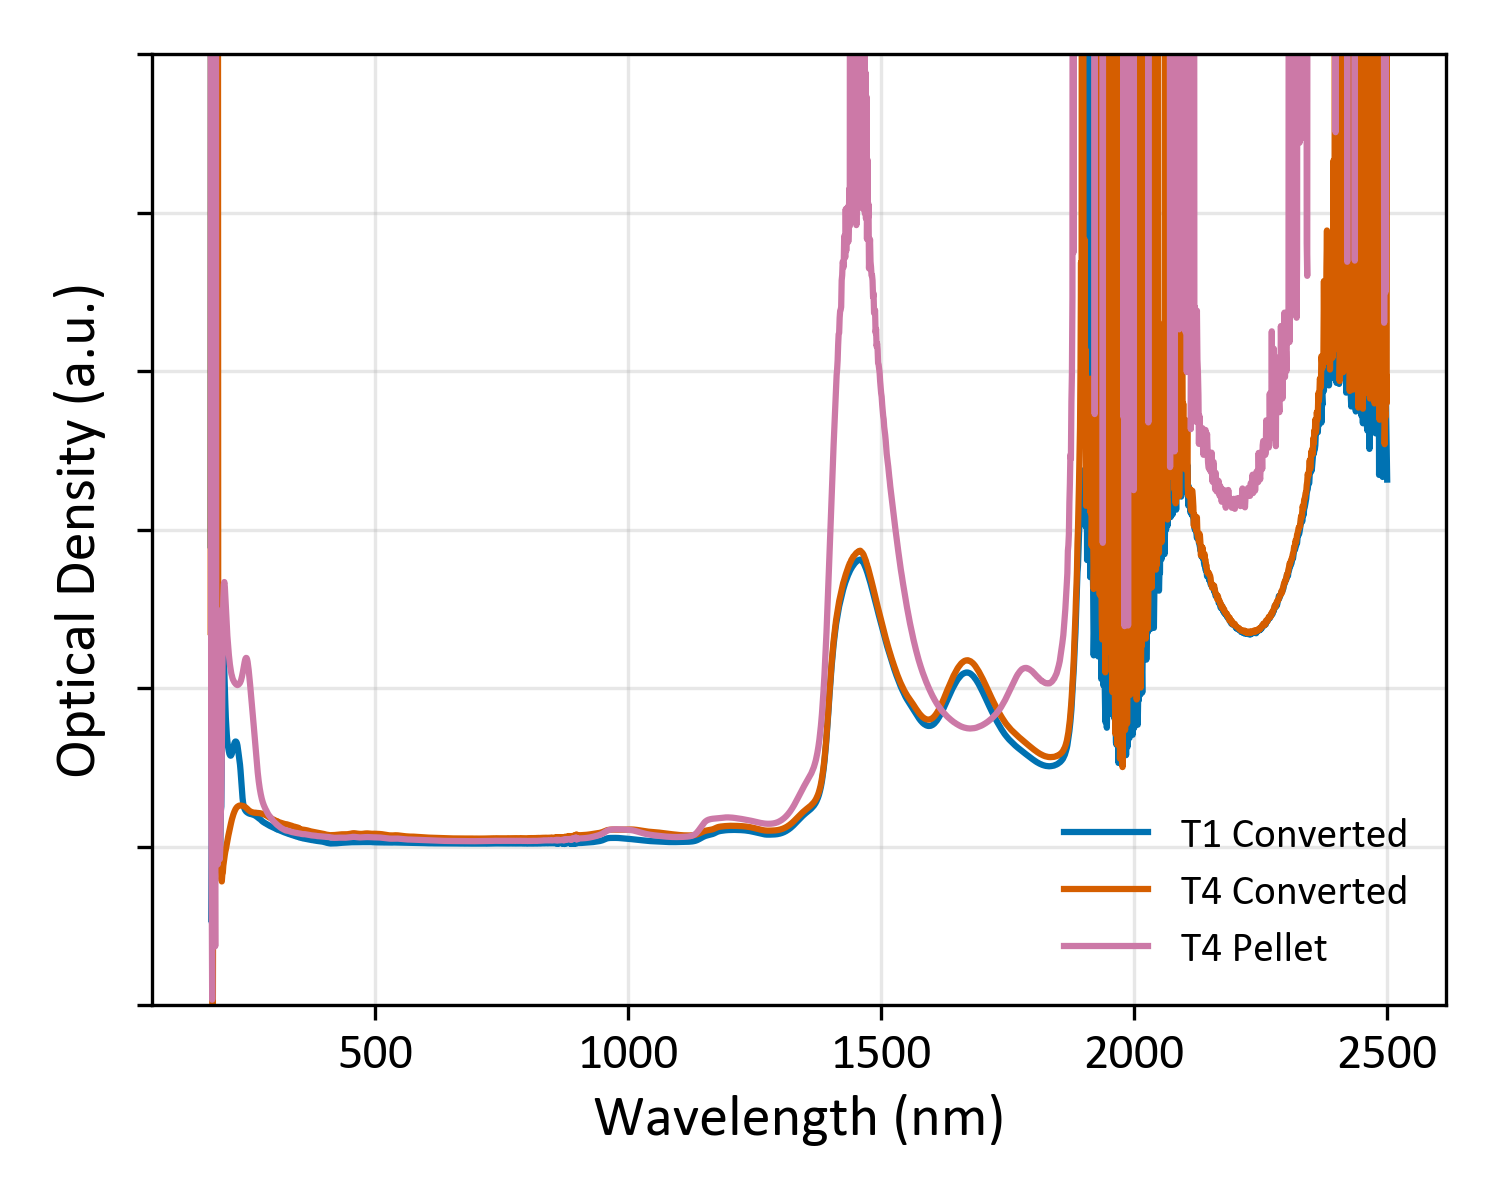

In [242]:
spectra_config = [
    # =========================================================
    # 1. KIT SAMPLES (2024-05-31)
    # =========================================================
     ('20240531_KIT_Samples_T1Converted',     'T1 Converted', 0,     '#0072B2', '-',0,0),
     ('20240531_KIT_Samples_T4Converted',     'T4 Converted', 0,     '#D55E00', '-',0,0),
     ('20240531_KIT_Samples_T4ConvertedPellet','T4 Pellet', 0,       '#CC79A7', '-',0,0),
     #('20240531_KIT_Samples_T4ConvertedPelletB','T4 Pellet B',     '#E69F00', '-'),

    # =========================================================
    # 2. CONVERTED SAMPLES (2024-06-13)
    # =========================================================
     #('20240613_KIT_ConvertedSamples_T1S',            'T1S',               '#0072B2', '-'),
     #('20240613_KIT_ConvertedSamples_T4S',            'T4S',               '#D55E00', '-'),
     #('20240613_KIT_ConvertedSamples_T4P',            'T4P',               '#009E73', '-'),

    # =========================================================
    # 3. FILM CONVERTED SAMPLES (2024-06-14)
    # =========================================================
     #('20240614_KIT_FilmConvertedSamples_FilmT1S',             'Film T1S (SWCNT)', '#0072B2', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT1SConverted',     'Film T1S Conv',    '#0072B2', '--'),
     #('20240614_KIT_FilmConvertedSamples_FilmT2S',             'Film T2S (SWCNT)', '#D55E00', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT2SConverted',     'Film T2S Conv',    '#D55E00', '--'),
     #('20240614_KIT_FilmConvertedSamples_FilmT9M',             'Film T9M (SWCNT)', '#009E73', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT9MConverted',     'Film T9M Conv',    '#009E73', '--'),
      
    # =========================================================
    # 5. DIALYSIS & POST-DIAL SAMPLES (2025-03-21)
    # =========================================================
    #('20250321_LastDialisysAndSamplePostDial_DWCNT_Megasonicated_KIT_Dial', 'Megasonicated Dial', '#CC79A7', '-'),
]

Selection = []
for key, name, wcorr, col, ls, a_val, b_val in spectra_config:
    if key in spectra_dict:
        s = spectra_dict[key].copy()
        s.N = name
        s.color = col
        s.linestyle = ls
        s.wcorr = wcorr
        s.a = a_val
        s.b = b_val
        Selection.append(s)
    else:
        print(f"Advertencia: El espectro '{key}' no existe.")



# --- PIPELINE DE PROCESAMIENTO (Opcional) ---
# Selection = TrimSpectra(Selection, xmin=400, xmax=1600)
# Selection = SubtractMinimum(Selection, xmin=1400, xmax=1550)
#Selection = NormalizeSpectra(Selection, xmin=900, xmax=1100, mode="M")

# 3. GRAFICAR
if len(Selection) > 0:
    PlotSpectra(
        spectra_list=Selection,
        mode="W",          # Muestra nm abajo y eV arriba
        style=poster_style,
        title="Absorption Spectra",
        offset_step=0.0,     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros,
        ymin=-1,
        ymax=5,
        hide_yticks=True,
        save_path='AbsFigures/Figure1_DispSamplesH2O.png'

    )

Saved: AbsFigures/Figure2_DispSamplesD2O_Normed.png


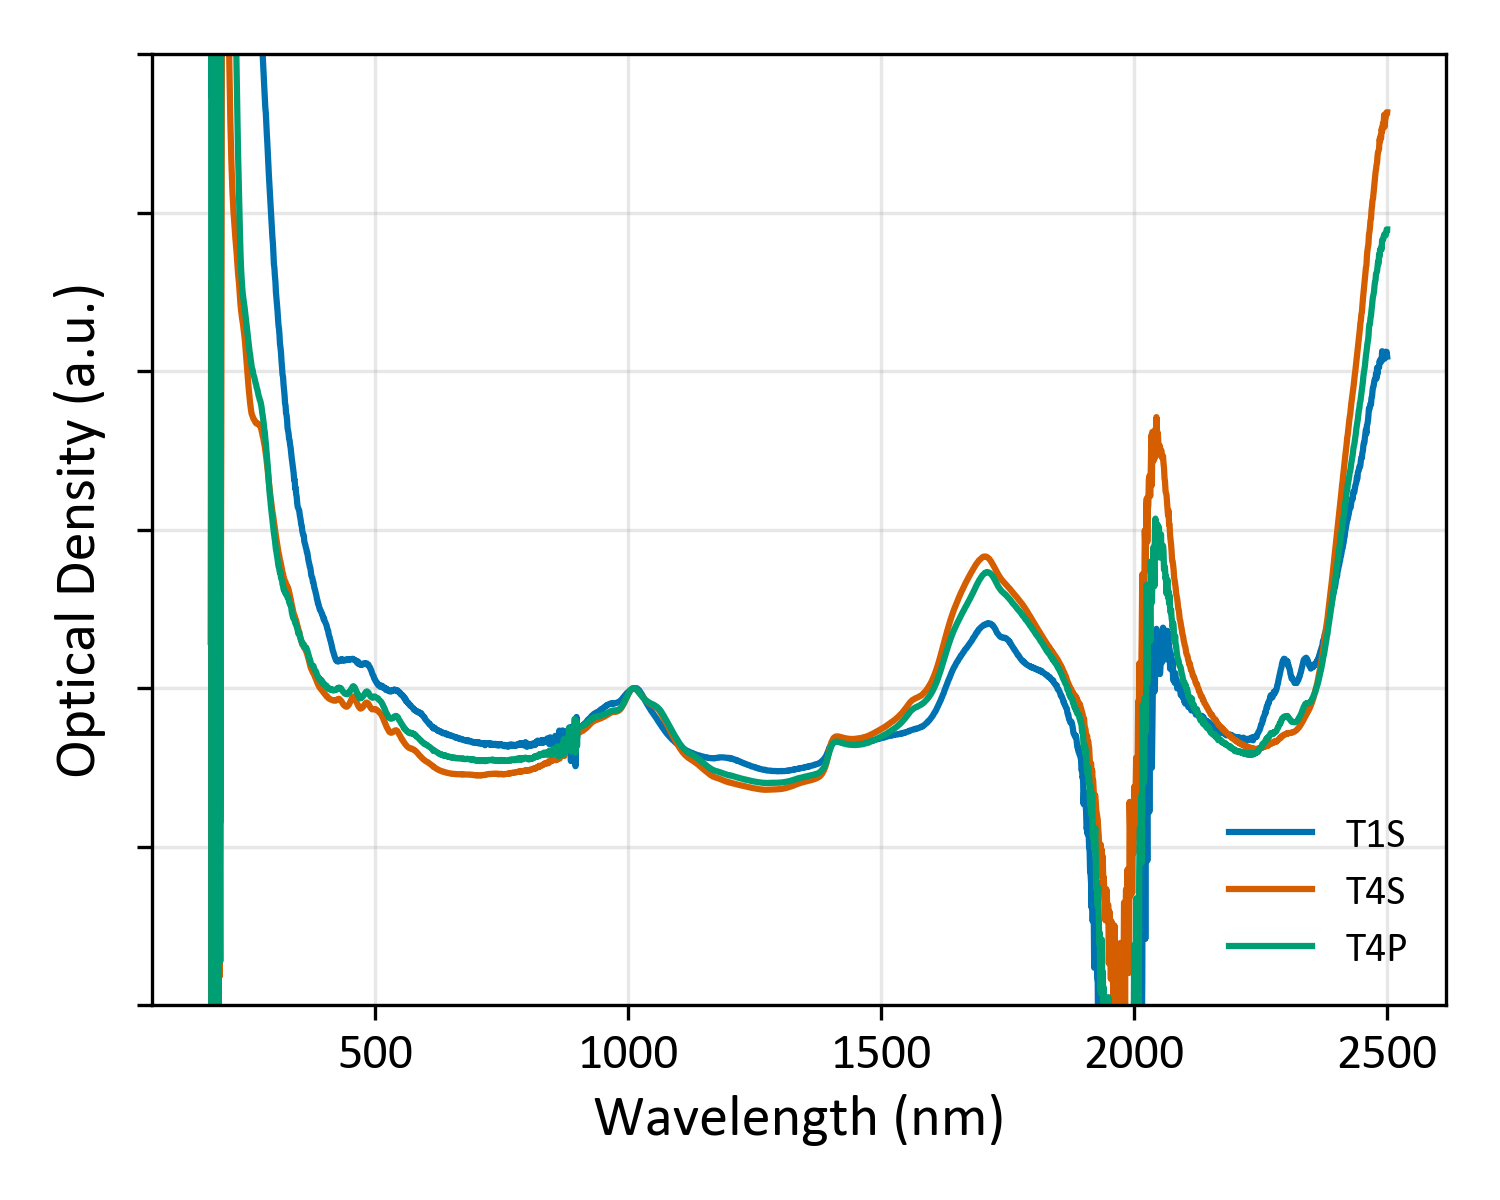

In [243]:
spectra_config = [
    # =========================================================
    # 1. KIT SAMPLES (2024-05-31)
    # =========================================================
     #('20240531_KIT_Samples_T1Converted',     'T1 Converted',      '#0072B2', '-'),
     #('20240531_KIT_Samples_T4Converted',     'T4 Converted',      '#D55E00', '-'),
     #('20240531_KIT_Samples_T4ConvertedPellet','T4 Pellet',        '#CC79A7', '-'),
     #('20240531_KIT_Samples_T4ConvertedPelletB','T4 Pellet B',     '#E69F00', '-'),

    # =========================================================
    # 2. CONVERTED SAMPLES (2024-06-13)
    # =========================================================
     ('20240613_KIT_ConvertedSamples_T1S',            'T1S', 0,              '#0072B2', '-',0,0),
     ('20240613_KIT_ConvertedSamples_T4S',            'T4S', 0,              '#D55E00', '-',0,0),
     ('20240613_KIT_ConvertedSamples_T4P',            'T4P', 0,              '#009E73', '-',0,0),

    # =========================================================
    # 3. FILM CONVERTED SAMPLES (2024-06-14)
    # =========================================================
     #('20240614_KIT_FilmConvertedSamples_FilmT1S',             'Film T1S (SWCNT)', '#0072B2', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT1SConverted',     'Film T1S Conv',    '#0072B2', '--'),
     #('20240614_KIT_FilmConvertedSamples_FilmT2S',             'Film T2S (SWCNT)', '#D55E00', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT2SConverted',     'Film T2S Conv',    '#D55E00', '--'),
     #('20240614_KIT_FilmConvertedSamples_FilmT9M',             'Film T9M (SWCNT)', '#009E73', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT9MConverted',     'Film T9M Conv',    '#009E73', '--'),
      
    # =========================================================
    # 5. DIALYSIS & POST-DIAL SAMPLES (2025-03-21)
    # =========================================================
    #('20250321_LastDialisysAndSamplePostDial_DWCNT_Megasonicated_KIT_Dial', 'Megasonicated Dial', '#CC79A7', '-'),
]

Selection = []
for key, name, wcorr, col, ls, a_val, b_val in spectra_config:
    if key in spectra_dict:
        s = spectra_dict[key].copy()
        s.N = name
        s.color = col
        s.linestyle = ls
        s.wcorr = wcorr
        s.a = a_val
        s.b = b_val
        Selection.append(s)
    else:
        print(f"Advertencia: El espectro '{key}' no existe.")


# --- PIPELINE DE PROCESAMIENTO (Opcional) ---
# Selection = TrimSpectra(Selection, xmin=400, xmax=1600)
# Selection = SubtractMinimum(Selection, xmin=1400, xmax=1550)
Selection = NormalizeSpectra(Selection, xmin=900, xmax=1100, mode="M")

# 3. GRAFICAR
if len(Selection) > 0:
    PlotSpectra(
        spectra_list=Selection,
        mode="W",          # Muestra nm abajo y eV arriba
        style=poster_style,
        title="Absorption Spectra",
        offset_step=0.0,     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros,
        ymin=-1,
        ymax=5,
                     hide_yticks=True,
                             save_path='AbsFigures/Figure2_DispSamplesD2O_Normed.png'

     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros
    )

Saved: AbsFigures/Figure3_FilmSamples.png


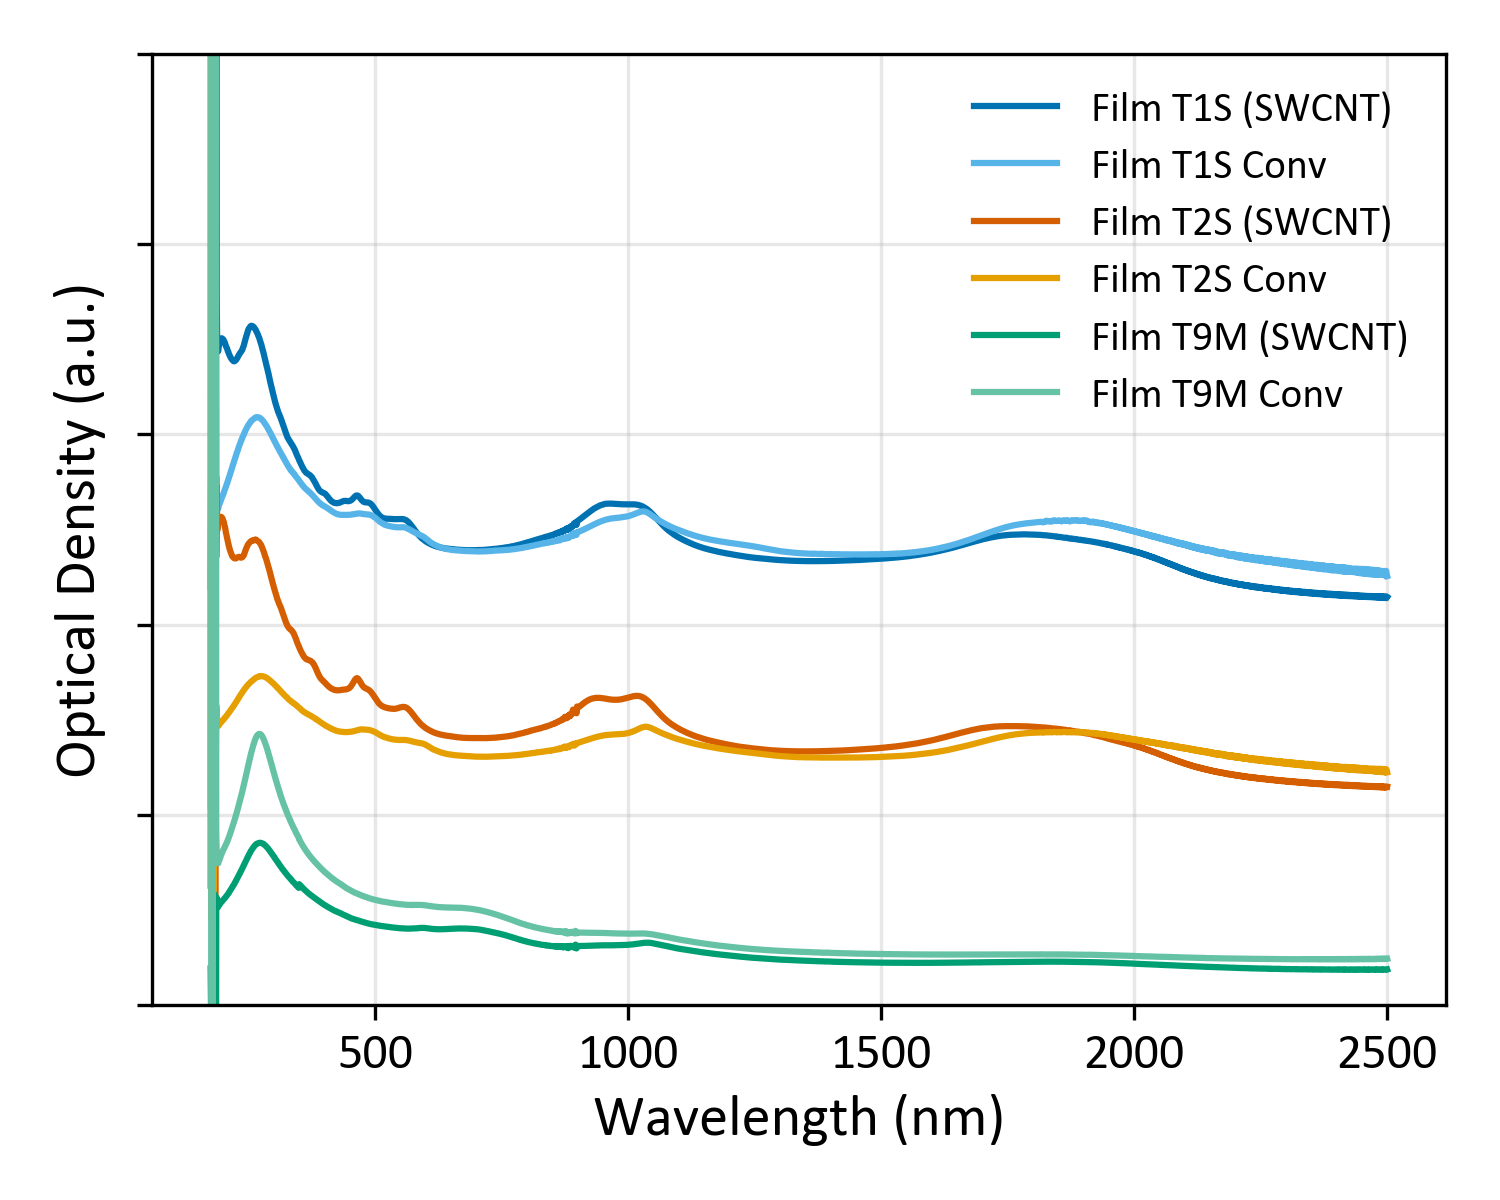

In [244]:
spectra_config = [
    # =========================================================
    # 1. KIT SAMPLES (2024-05-31)
    # =========================================================
     #('20240531_KIT_Samples_T1Converted',     'T1 Converted',      '#0072B2', '-'),
     #('20240531_KIT_Samples_T4Converted',     'T4 Converted',      '#D55E00', '-'),
     #('20240531_KIT_Samples_T4ConvertedPellet','T4 Pellet',        '#CC79A7', '-'),
     #('20240531_KIT_Samples_T4ConvertedPelletB','T4 Pellet B',     '#E69F00', '-'),

    # =========================================================
    # 2. CONVERTED SAMPLES (2024-06-13)
    # =========================================================
     #('20240613_KIT_ConvertedSamples_T1S',            'T1S',               '#0072B2', '-'),
     #('20240613_KIT_ConvertedSamples_T4S',            'T4S',               '#D55E00', '-'),
     #('20240613_KIT_ConvertedSamples_T4P',            'T4P',               '#009E73', '-'),

    # =========================================================
    # 3. FILM CONVERTED SAMPLES (2024-06-14)
    # =========================================================
     ('20240614_KIT_FilmConvertedSamples_FilmT1S',             'Film T1S (SWCNT)', 0,'#0072B2', '-',0,0),
     ('20240614_KIT_FilmConvertedSamples_FilmT1SConverted',     'Film T1S Conv',   0, '#56B4E9', '-',0,0),
     ('20240614_KIT_FilmConvertedSamples_FilmT2S',             'Film T2S (SWCNT)',0, '#D55E00', '-',0,0),
     ('20240614_KIT_FilmConvertedSamples_FilmT2SConverted',     'Film T2S Conv',  0,  '#E69F00', '-',0,0),
     ('20240614_KIT_FilmConvertedSamples_FilmT9M',             'Film T9M (SWCNT)',0, '#009E73', '-',0,0),
     ('20240614_KIT_FilmConvertedSamples_FilmT9MConverted',     'Film T9M Conv',  0,  '#66C2A5', '-',0,0),
      
    # =========================================================
    # 5. DIALYSIS & POST-DIAL SAMPLES (2025-03-21)
    # =========================================================
    #('20250321_LastDialisysAndSamplePostDial_DWCNT_Megasonicated_KIT_Dial', 'Megasonicated Dial', '#CC79A7', '-'),
]


Selection = []
for key, name, wcorr, col, ls, a_val, b_val in spectra_config:
    if key in spectra_dict:
        s = spectra_dict[key].copy()
        s.N = name
        s.color = col
        s.linestyle = ls
        s.wcorr = wcorr
        s.a = a_val
        s.b = b_val
        Selection.append(s)
    else:
        print(f"Advertencia: El espectro '{key}' no existe.")



# --- PIPELINE DE PROCESAMIENTO (Opcional) ---
# Selection = TrimSpectra(Selection, xmin=400, xmax=1600)
# Selection = SubtractMinimum(Selection, xmin=1400, xmax=1550)
#Selection = NormalizeSpectra(Selection, xmin=900, xmax=1100, mode="M")

# Offset manual por pares
Selection[0].Y = Selection[0].Y- 0
Selection[1].Y = Selection[1].Y- 0
Selection[2].Y = Selection[2].Y- 1
Selection[3].Y = Selection[3].Y- 1
Selection[4].Y = Selection[4].Y- 2
Selection[5].Y = Selection[5].Y- 2

# 3. GRAFICAR
if len(Selection) > 0:
    PlotSpectra(
        spectra_list=Selection,
        mode="W",          # Muestra nm abajo y eV arriba
        style=poster_style,
        title="Absorption Spectra",
        offset_step=-0.0,     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros,
        ymin=-2,
        ymax=3,
                     hide_yticks=True, 
                                                  save_path='AbsFigures/Figure3_FilmSamples.png'

     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros
    )

Saved: AbsFigures/Figure4_T1sfilms.png


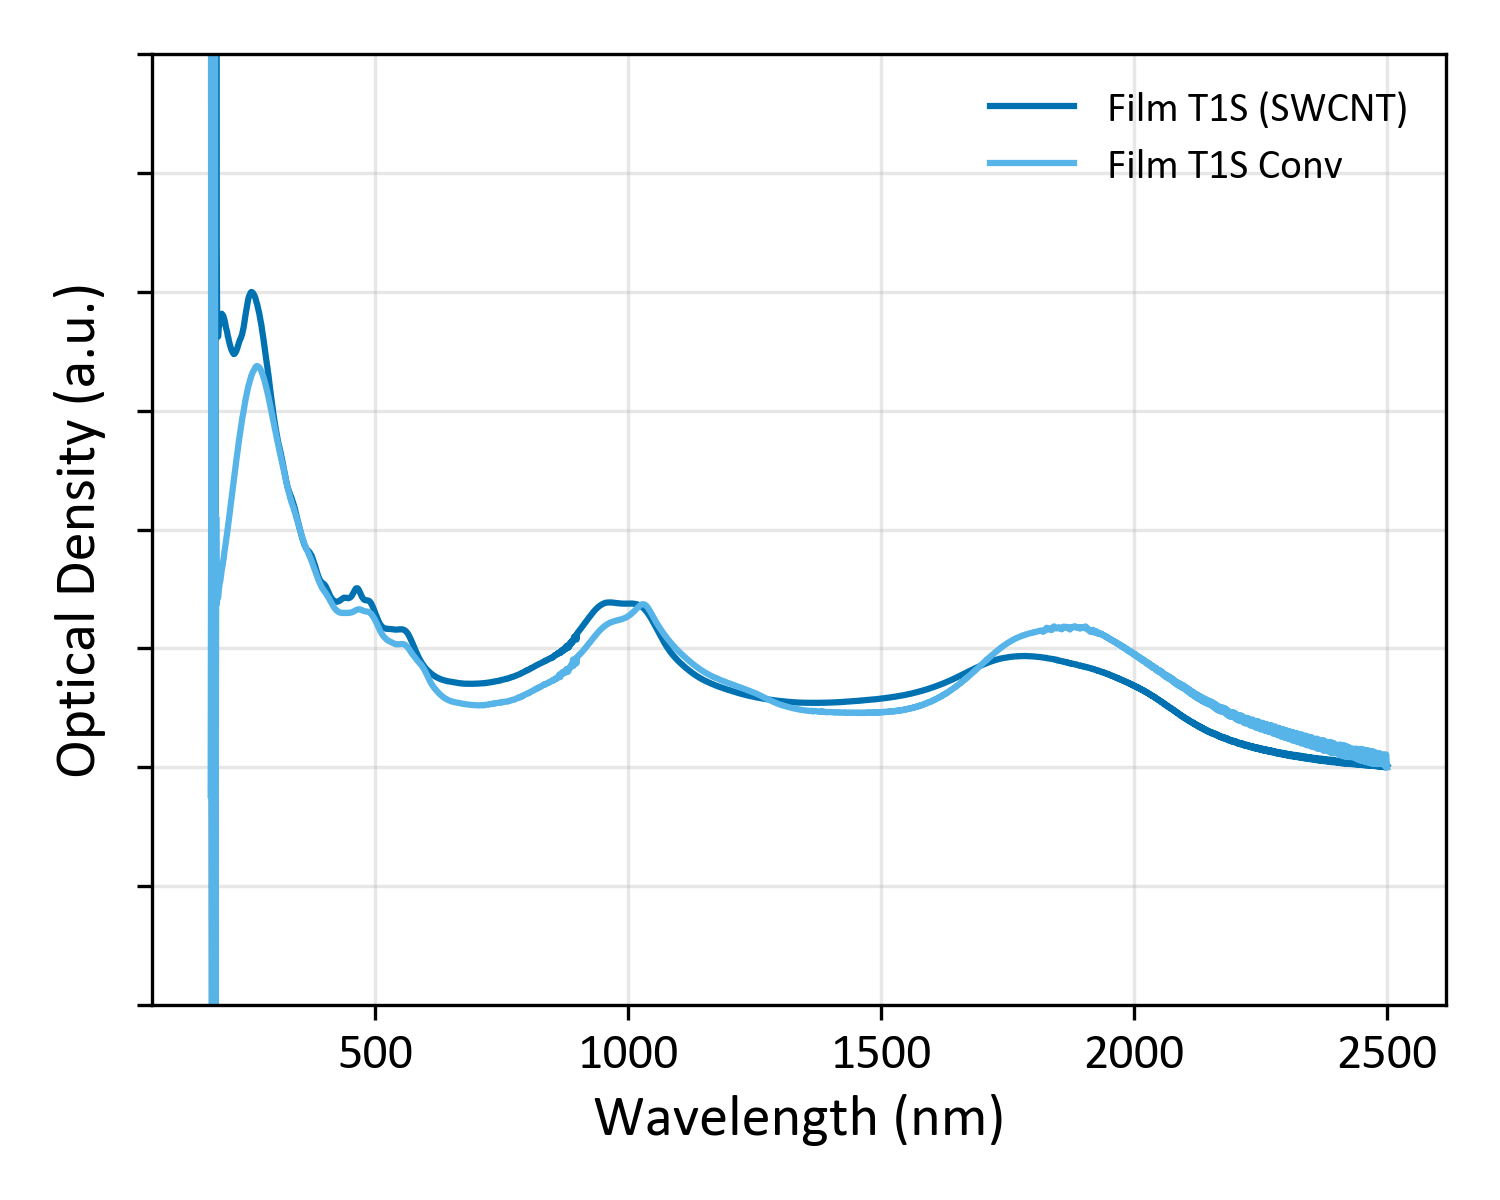

In [245]:
spectra_config = [
    # =========================================================
    # 1. KIT SAMPLES (2024-05-31)
    # =========================================================
     #('20240531_KIT_Samples_T1Converted',     'T1 Converted',      '#0072B2', '-'),
     #('20240531_KIT_Samples_T4Converted',     'T4 Converted',      '#D55E00', '-'),
     #('20240531_KIT_Samples_T4ConvertedPellet','T4 Pellet',        '#CC79A7', '-'),
     #('20240531_KIT_Samples_T4ConvertedPelletB','T4 Pellet B',     '#E69F00', '-'),

    # =========================================================
    # 2. CONVERTED SAMPLES (2024-06-13)
    # =========================================================
     #('20240613_KIT_ConvertedSamples_T1S',            'T1S',               '#0072B2', '-'),
     #('20240613_KIT_ConvertedSamples_T4S',            'T4S',               '#D55E00', '-'),
     #('20240613_KIT_ConvertedSamples_T4P',            'T4P',               '#009E73', '-'),

    # =========================================================
    # 3. FILM CONVERTED SAMPLES (2024-06-14)
    # =========================================================
     ('20240614_KIT_FilmConvertedSamples_FilmT1S',             'Film T1S (SWCNT)',0, '#0072B2', '-',0,0),
     ('20240614_KIT_FilmConvertedSamples_FilmT1SConverted',     'Film T1S Conv',   0, '#56B4E9', '-',0,0),
     #('20240614_KIT_FilmConvertedSamples_FilmT2S',             'Film T2S (SWCNT)', '#D55E00', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT2SConverted',     'Film T2S Conv',    '#E69F00', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT9M',             'Film T9M (SWCNT)', '#009E73', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT9MConverted',     'Film T9M Conv',    '#66C2A5', '-'),
      
    # =========================================================
    # 5. DIALYSIS & POST-DIAL SAMPLES (2025-03-21)
    # =========================================================
    #('20250321_LastDialisysAndSamplePostDial_DWCNT_Megasonicated_KIT_Dial', 'Megasonicated Dial', '#CC79A7', '-'),
]

Selection = []
for key, name, wcorr, col, ls, a_val, b_val in spectra_config:
    if key in spectra_dict:
        s = spectra_dict[key].copy()
        s.N = name
        s.color = col
        s.linestyle = ls
        s.wcorr = wcorr
        s.a = a_val
        s.b = b_val
        Selection.append(s)
    else:
        print(f"Advertencia: El espectro '{key}' no existe.")



# --- PIPELINE DE PROCESAMIENTO (Opcional) ---
# Selection = TrimSpectra(Selection, xmin=400, xmax=1600)
Selection = SubtractMinimum(Selection, xmin=2490, xmax=2500)
Selection = NormalizeSpectra(Selection, xmin=220, xmax=2500, mode="I")


# 3. GRAFICAR
if len(Selection) > 0:
    PlotSpectra(
        spectra_list=Selection,
        mode="W",          # Muestra nm abajo y eV arriba
        style=poster_style,
        title="Absorption Spectra",
        offset_step=-0.0,     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros,
        ymin=-0.001,
        ymax=0.003,         hide_yticks=True,
        save_path='AbsFigures/Figure4_T1sfilms.png'


     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros
    )

Saved: AbsFigures/Figure5_T2sfilms.png


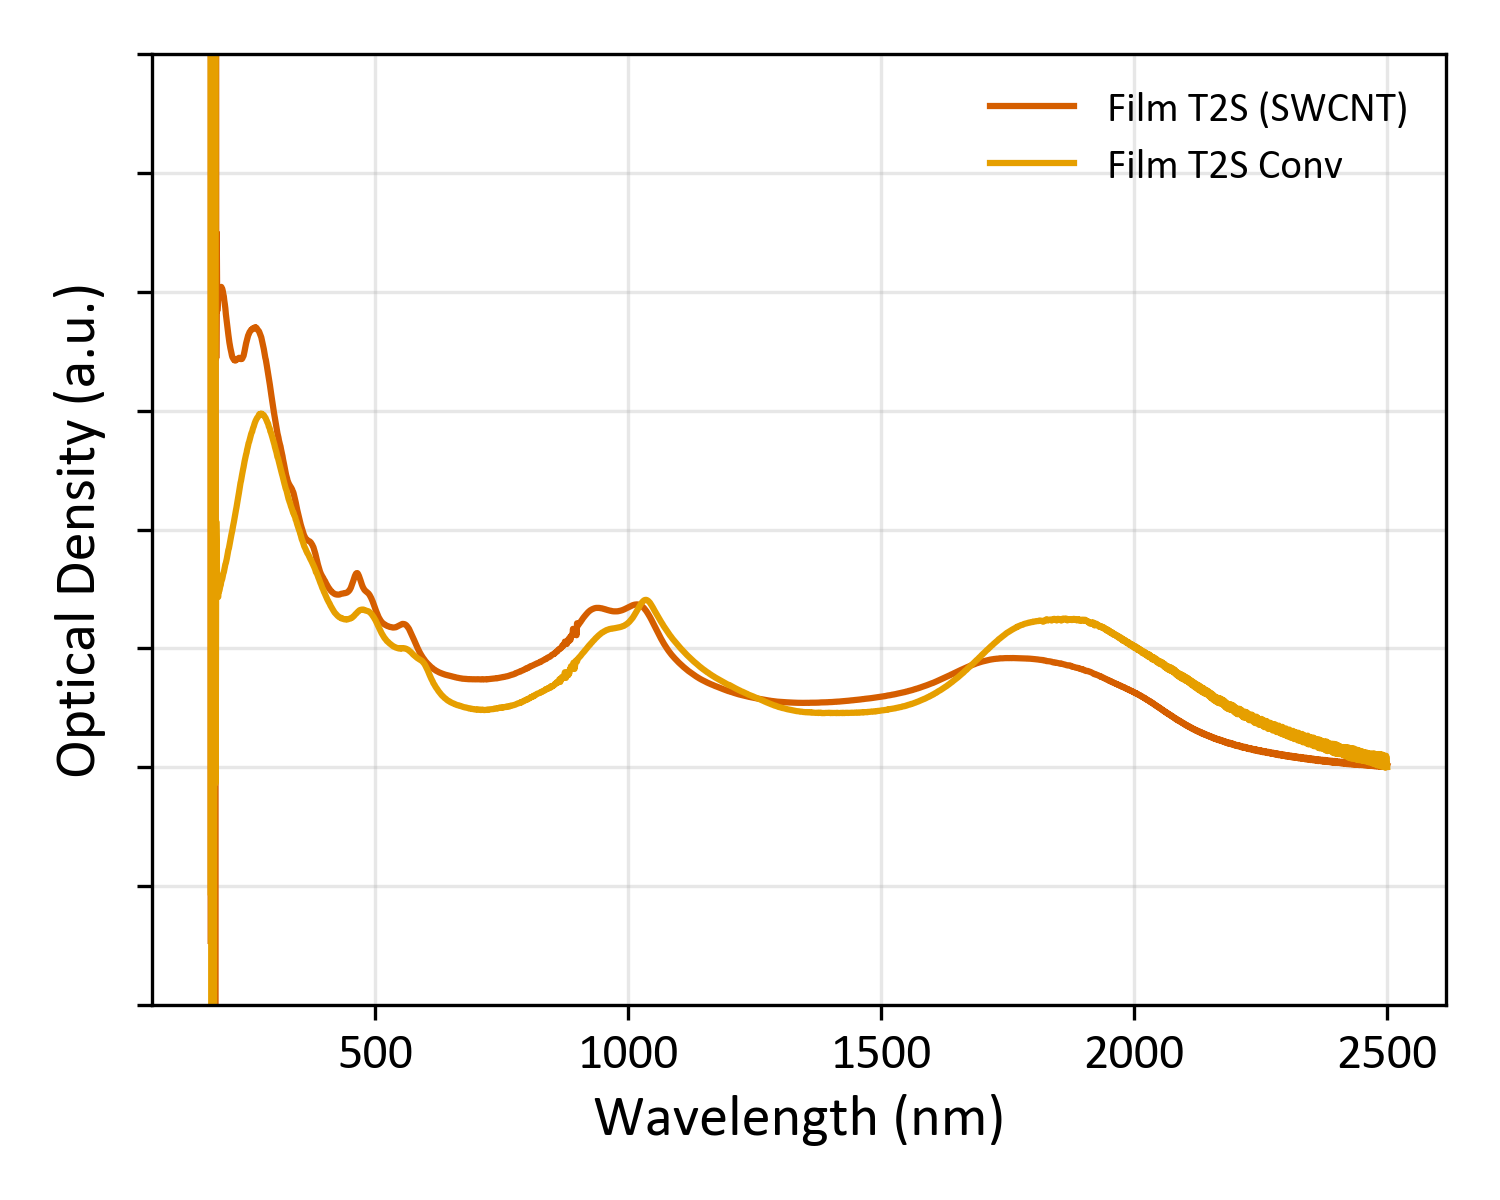

In [246]:
spectra_config = [
    # =========================================================
    # 1. KIT SAMPLES (2024-05-31)
    # =========================================================
     #('20240531_KIT_Samples_T1Converted',     'T1 Converted',      '#0072B2', '-'),
     #('20240531_KIT_Samples_T4Converted',     'T4 Converted',      '#D55E00', '-'),
     #('20240531_KIT_Samples_T4ConvertedPellet','T4 Pellet',        '#CC79A7', '-'),
     #('20240531_KIT_Samples_T4ConvertedPelletB','T4 Pellet B',     '#E69F00', '-'),

    # =========================================================
    # 2. CONVERTED SAMPLES (2024-06-13)
    # =========================================================
     #('20240613_KIT_ConvertedSamples_T1S',            'T1S',               '#0072B2', '-'),
     #('20240613_KIT_ConvertedSamples_T4S',            'T4S',               '#D55E00', '-'),
     #('20240613_KIT_ConvertedSamples_T4P',            'T4P',               '#009E73', '-'),

    # =========================================================
    # 3. FILM CONVERTED SAMPLES (2024-06-14)
    # =========================================================
     #('20240614_KIT_FilmConvertedSamples_FilmT1S',             'Film T1S (SWCNT)', '#0072B2', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT1SConverted',     'Film T1S Conv',    '#56B4E9', '-'),
     ('20240614_KIT_FilmConvertedSamples_FilmT2S',             'Film T2S (SWCNT)', 0,'#D55E00', '-',0,0),
     ('20240614_KIT_FilmConvertedSamples_FilmT2SConverted',     'Film T2S Conv',  0,  '#E69F00', '-',0,0),
     #('20240614_KIT_FilmConvertedSamples_FilmT9M',             'Film T9M (SWCNT)', '#009E73', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT9MConverted',     'Film T9M Conv',    '#66C2A5', '-'),
      
    # =========================================================
    # 5. DIALYSIS & POST-DIAL SAMPLES (2025-03-21)
    # =========================================================
    #('20250321_LastDialisysAndSamplePostDial_DWCNT_Megasonicated_KIT_Dial', 'Megasonicated Dial', '#CC79A7', '-'),
]

Selection = []
for key, name, wcorr, col, ls, a_val, b_val in spectra_config:
    if key in spectra_dict:
        s = spectra_dict[key].copy()
        s.N = name
        s.color = col
        s.linestyle = ls
        s.wcorr = wcorr
        s.a = a_val
        s.b = b_val
        Selection.append(s)
    else:
        print(f"Advertencia: El espectro '{key}' no existe.")



# --- PIPELINE DE PROCESAMIENTO (Opcional) ---
# Selection = TrimSpectra(Selection, xmin=400, xmax=1600)
Selection = SubtractMinimum(Selection, xmin=2490, xmax=2500)
Selection = NormalizeSpectra(Selection, xmin=220, xmax=2500, mode="I")


# 3. GRAFICAR
if len(Selection) > 0:
    PlotSpectra(
        spectra_list=Selection,
        mode="W",          # Muestra nm abajo y eV arriba
        style=poster_style,
        title="Absorption Spectra",
        offset_step=-0.0,
        ymin=-0.001,
        ymax=0.003,        hide_yticks=True,
                save_path='AbsFigures/Figure5_T2sfilms.png'

     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros
    )

Saved: AbsFigures/Figure6_T9mfilms.png


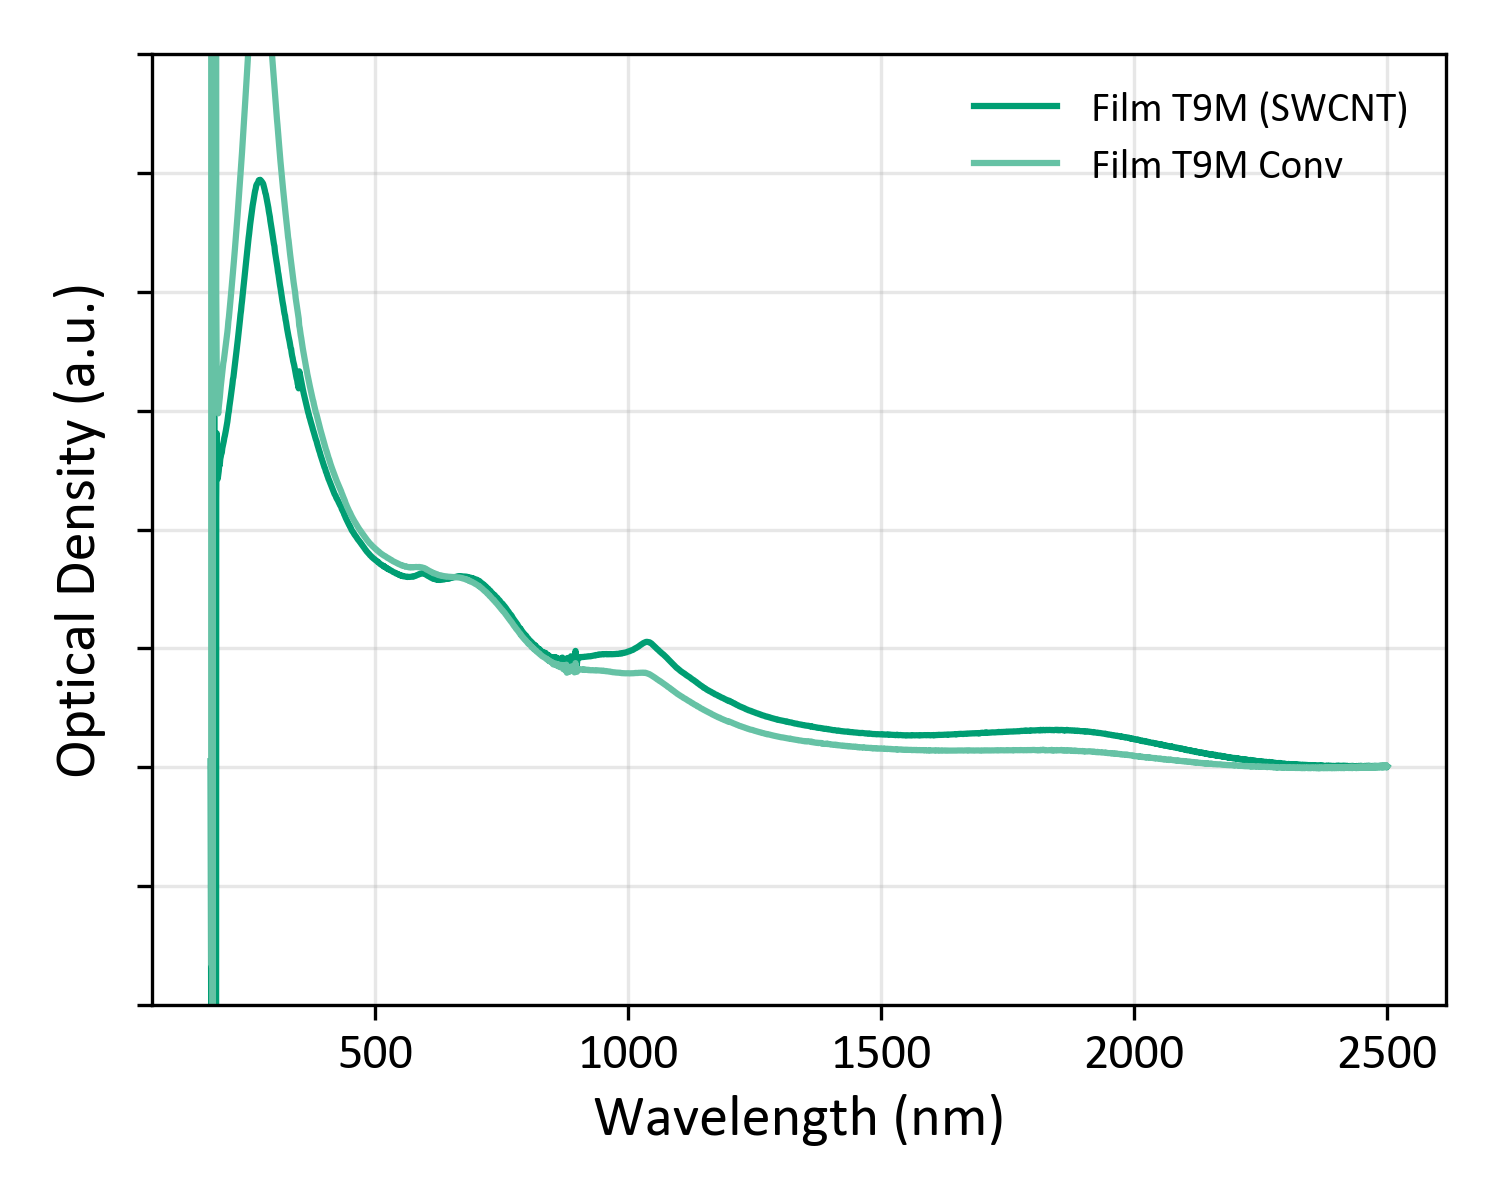

In [247]:
spectra_config = [
    # =========================================================
    # 1. KIT SAMPLES (2024-05-31)
    # =========================================================
     #('20240531_KIT_Samples_T1Converted',     'T1 Converted',      '#0072B2', '-'),
     #('20240531_KIT_Samples_T4Converted',     'T4 Converted',      '#D55E00', '-'),
     #('20240531_KIT_Samples_T4ConvertedPellet','T4 Pellet',        '#CC79A7', '-'),
     #('20240531_KIT_Samples_T4ConvertedPelletB','T4 Pellet B',     '#E69F00', '-'),

    # =========================================================
    # 2. CONVERTED SAMPLES (2024-06-13)
    # =========================================================
     #('20240613_KIT_ConvertedSamples_T1S',            'T1S',               '#0072B2', '-'),
     #('20240613_KIT_ConvertedSamples_T4S',            'T4S',               '#D55E00', '-'),
     #('20240613_KIT_ConvertedSamples_T4P',            'T4P',               '#009E73', '-'),

    # =========================================================
    # 3. FILM CONVERTED SAMPLES (2024-06-14)
    # =========================================================
     #('20240614_KIT_FilmConvertedSamples_FilmT1S',             'Film T1S (SWCNT)', '#0072B2', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT1SConverted',     'Film T1S Conv',    '#56B4E9', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT2S',             'Film T2S (SWCNT)', '#D55E00', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT2SConverted',     'Film T2S Conv',    '#E69F00', '-'),
     ('20240614_KIT_FilmConvertedSamples_FilmT9M',             'Film T9M (SWCNT)',0, '#009E73', '-',0,0),
     ('20240614_KIT_FilmConvertedSamples_FilmT9MConverted',     'Film T9M Conv',   0, '#66C2A5', '-',0,0),
      
    # =========================================================
    # 5. DIALYSIS & POST-DIAL SAMPLES (2025-03-21)
    # =========================================================
    #('20250321_LastDialisysAndSamplePostDial_DWCNT_Megasonicated_KIT_Dial', 'Megasonicated Dial', '#CC79A7', '-'),
]

Selection = []
for key, name, wcorr, col, ls, a_val, b_val in spectra_config:
    if key in spectra_dict:
        s = spectra_dict[key].copy()
        s.N = name
        s.color = col
        s.linestyle = ls
        s.wcorr = wcorr
        s.a = a_val
        s.b = b_val
        Selection.append(s)
    else:
        print(f"Advertencia: El espectro '{key}' no existe.")


# --- PIPELINE DE PROCESAMIENTO (Opcional) ---
# Selection = TrimSpectra(Selection, xmin=400, xmax=1600)
Selection = SubtractMinimum(Selection, xmin=2490, xmax=2500)
Selection = NormalizeSpectra(Selection, xmin=220, xmax=2500, mode="I")


# 3. GRAFICAR
if len(Selection) > 0:
    PlotSpectra(
        spectra_list=Selection,
        mode="W",          # Muestra nm abajo y eV arriba
        style=poster_style,
        title="Absorption Spectra",
        offset_step=-0.0,     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros
        ymin=-0.001,
        ymax=0.003,        hide_yticks=True,
    save_path='AbsFigures/Figure6_T9mfilms.png'

     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros
    )

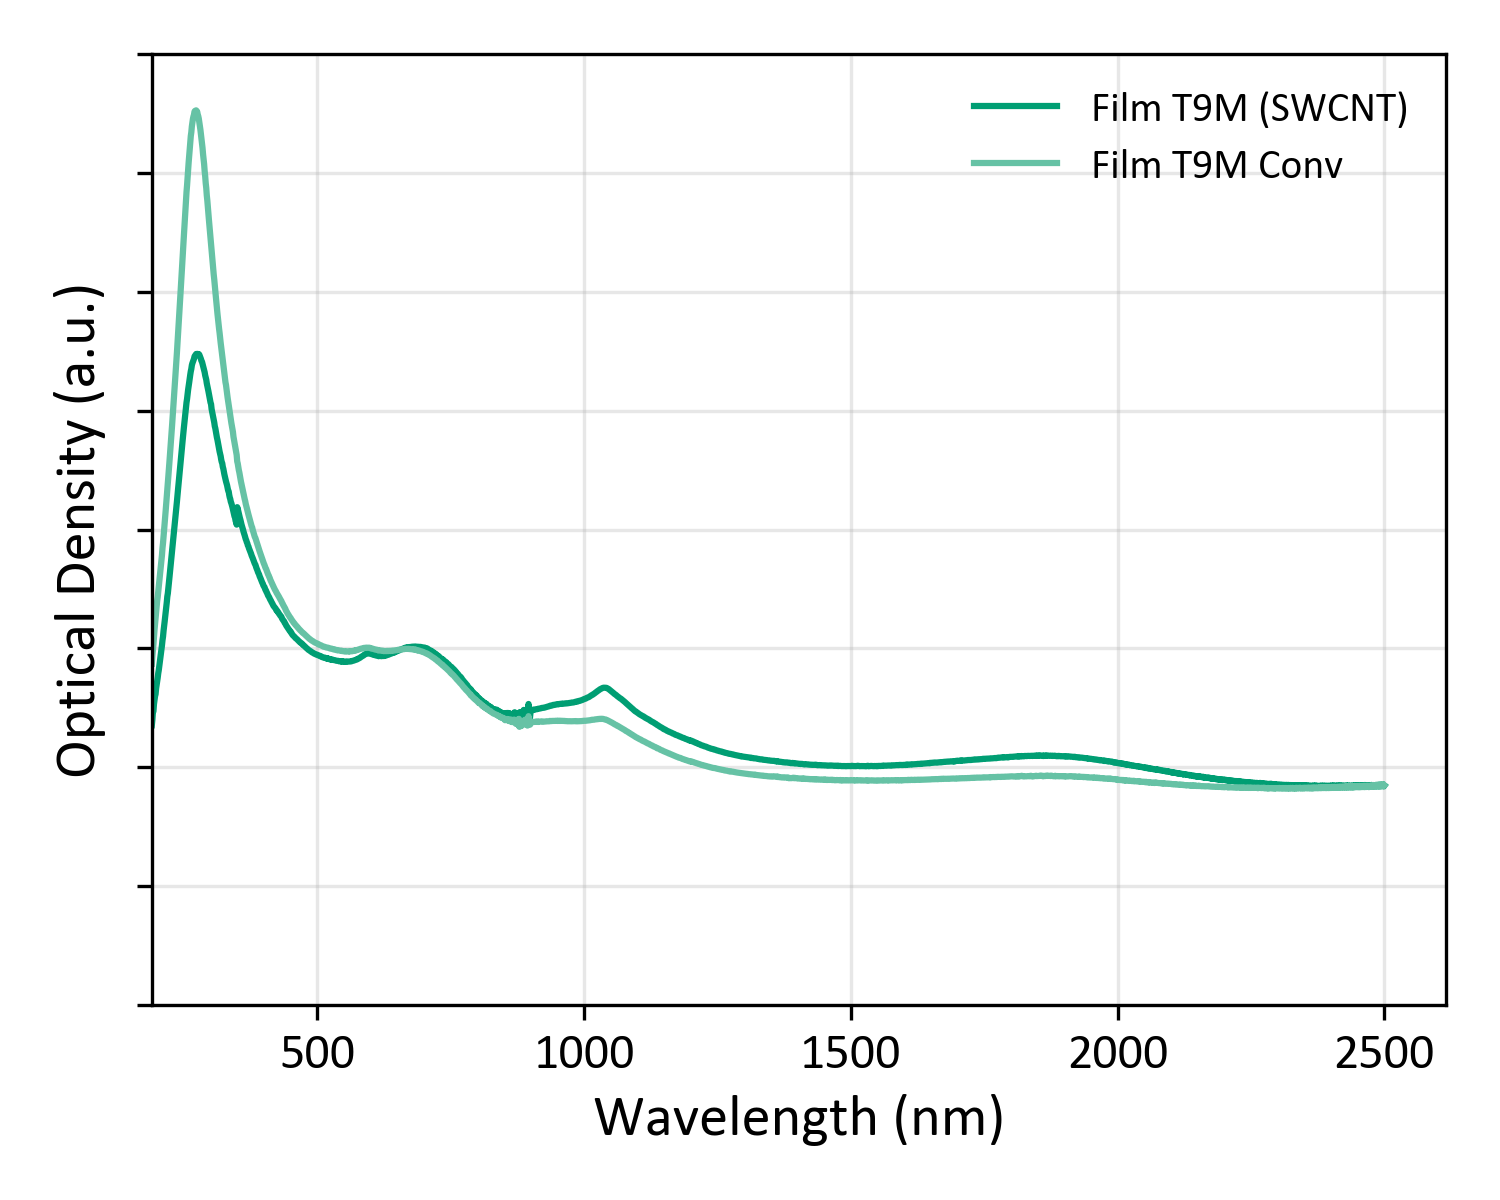

In [248]:
spectra_config = [
    # =========================================================
    # 1. KIT SAMPLES (2024-05-31)
    # =========================================================
     #('20240531_KIT_Samples_T1Converted',     'T1 Converted',      '#0072B2', '-'),
     #('20240531_KIT_Samples_T4Converted',     'T4 Converted',      '#D55E00', '-'),
     #('20240531_KIT_Samples_T4ConvertedPellet','T4 Pellet',        '#CC79A7', '-'),
     #('20240531_KIT_Samples_T4ConvertedPelletB','T4 Pellet B',     '#E69F00', '-'),

    # =========================================================
    # 2. CONVERTED SAMPLES (2024-06-13)
    # =========================================================
     #('20240613_KIT_ConvertedSamples_T1S',            'T1S',               '#0072B2', '-'),
     #('20240613_KIT_ConvertedSamples_T4S',            'T4S',               '#D55E00', '-'),
     #('20240613_KIT_ConvertedSamples_T4P',            'T4P',               '#009E73', '-'),

    # =========================================================
    # 3. FILM CONVERTED SAMPLES (2024-06-14)
    # =========================================================
     #('20240614_KIT_FilmConvertedSamples_FilmT1S',             'Film T1S (SWCNT)', '#0072B2', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT1SConverted',     'Film T1S Conv',    '#56B4E9', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT2S',             'Film T2S (SWCNT)', '#D55E00', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT2SConverted',     'Film T2S Conv',    '#E69F00', '-'),
     ('20240614_KIT_FilmConvertedSamples_FilmT9M',             'Film T9M (SWCNT)', 0,'#009E73', '-', .2,0),
     ('20240614_KIT_FilmConvertedSamples_FilmT9MConverted',     'Film T9M Conv',   0, '#66C2A5', '-', .2,0),
      
    # =========================================================
    # 5. DIALYSIS & POST-DIAL SAMPLES (2025-03-21)
    # =========================================================
    #('20250321_LastDialisysAndSamplePostDial_DWCNT_Megasonicated_KIT_Dial', 'Megasonicated Dial', '#CC79A7', '-'),
]

Selection = []
for key, name, wcorr, col, ls, a_val, b_val in spectra_config:
    if key in spectra_dict:
        s = spectra_dict[key].copy()
        s.N = name
        s.color = col
        s.linestyle = ls
        s.wcorr = wcorr
        s.a = a_val
        s.b = b_val
        Selection.append(s)
    else:
        print(f"Advertencia: El espectro '{key}' no existe.")


# --- PIPELINE DE PROCESAMIENTO (Opcional) ---
Selection = SubtractMinimum(Selection, xmin=2490, xmax=2500)
Selection = NormalizeSpectra(Selection, xmin=220, xmax=2500, mode="I")
Selection = TrimSpectra(Selection, xmin=190)
Selection = BackgroundCorrection(Selection)


# 3. GRAFICAR
if len(Selection) > 0:
    PlotSpectra(
        spectra_list=Selection,
        mode="W",          # Muestra nm abajo y eV arriba
        style=poster_style,
        title="Absorption Spectra",
        #ymax=0.004,
        #ymin=0,
        xmin=190,
        offset_step=-0.0,
                     ymin=-0.001,
        ymax=0.003,        hide_yticks=True
     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros
    )

In [249]:
import pandas as pd
# ============================================================
# 3. LOAD DATA & CREATE VARIABLES
# ============================================================
References = r"H:\FUBerlin\Measurements\UVvisNIR\References.csv"
try:
    calibration_df = pd.read_csv(
        References, sep=",", skiprows=2, header=None,
        names=["Water_Wavelength", "WaterInD2O", "Nicodenz_Wavelength", "Nicodenz",
               "Empty_Wavelength", "Empty_P2", "WaterFilled_Wavelength", "WaterFilled"]
    )
    cal_objects = {}
    for i in range(0, len(calibration_df.columns), 2):
        w_col = calibration_df.columns[i]
        a_col = calibration_df.columns[i + 1]
        df_temp = pd.DataFrame({"X": pd.to_numeric(calibration_df[w_col], errors="coerce"),
                                "Y": pd.to_numeric(calibration_df[a_col], errors="coerce")}).dropna().sort_values("X")
        cal_objects[a_col] = Spectrum(N=a_col, X=df_temp["X"].values, Y=df_temp["Y"].values)
    water_calibration = cal_objects["WaterInD2O"]
    nycodenz_calibration = cal_objects["Nicodenz"]

except Exception as e:
    print(f"Warning: Could not load calibration data: {e}")
    
# ============================================================
@dataclass
class Spectrum:
    N: str                  # Nombre o Label original
    X: np.ndarray           # X data
    Y: np.ndarray           # Y data
    wcorr: float = 0.0          # Factor de corrección de agua por defecto
    nzcorr: float = 0.0          # Factor de corrección de agua por defecto
    color: str = None       # Color para ploteo
    linestyle: str = None   # Estilo de línea
    a: float = 0.0          # Parámetro a opcional para fondo
    b: float = 0.0          # Parámetro b opcional para fondo

    def copy(self):
        return Spectrum(
            N=self.N, 
            X=self.X.copy(), 
            Y=self.Y.copy(), 
            wcorr= self.wcorr,
            nzcorr= self.nzcorr,
            color=self.color,         
            linestyle=self.linestyle,
            a=self.a,
            b=self.b
        )


Saved: CorrectedFigures_Dispersions/Absorption.png


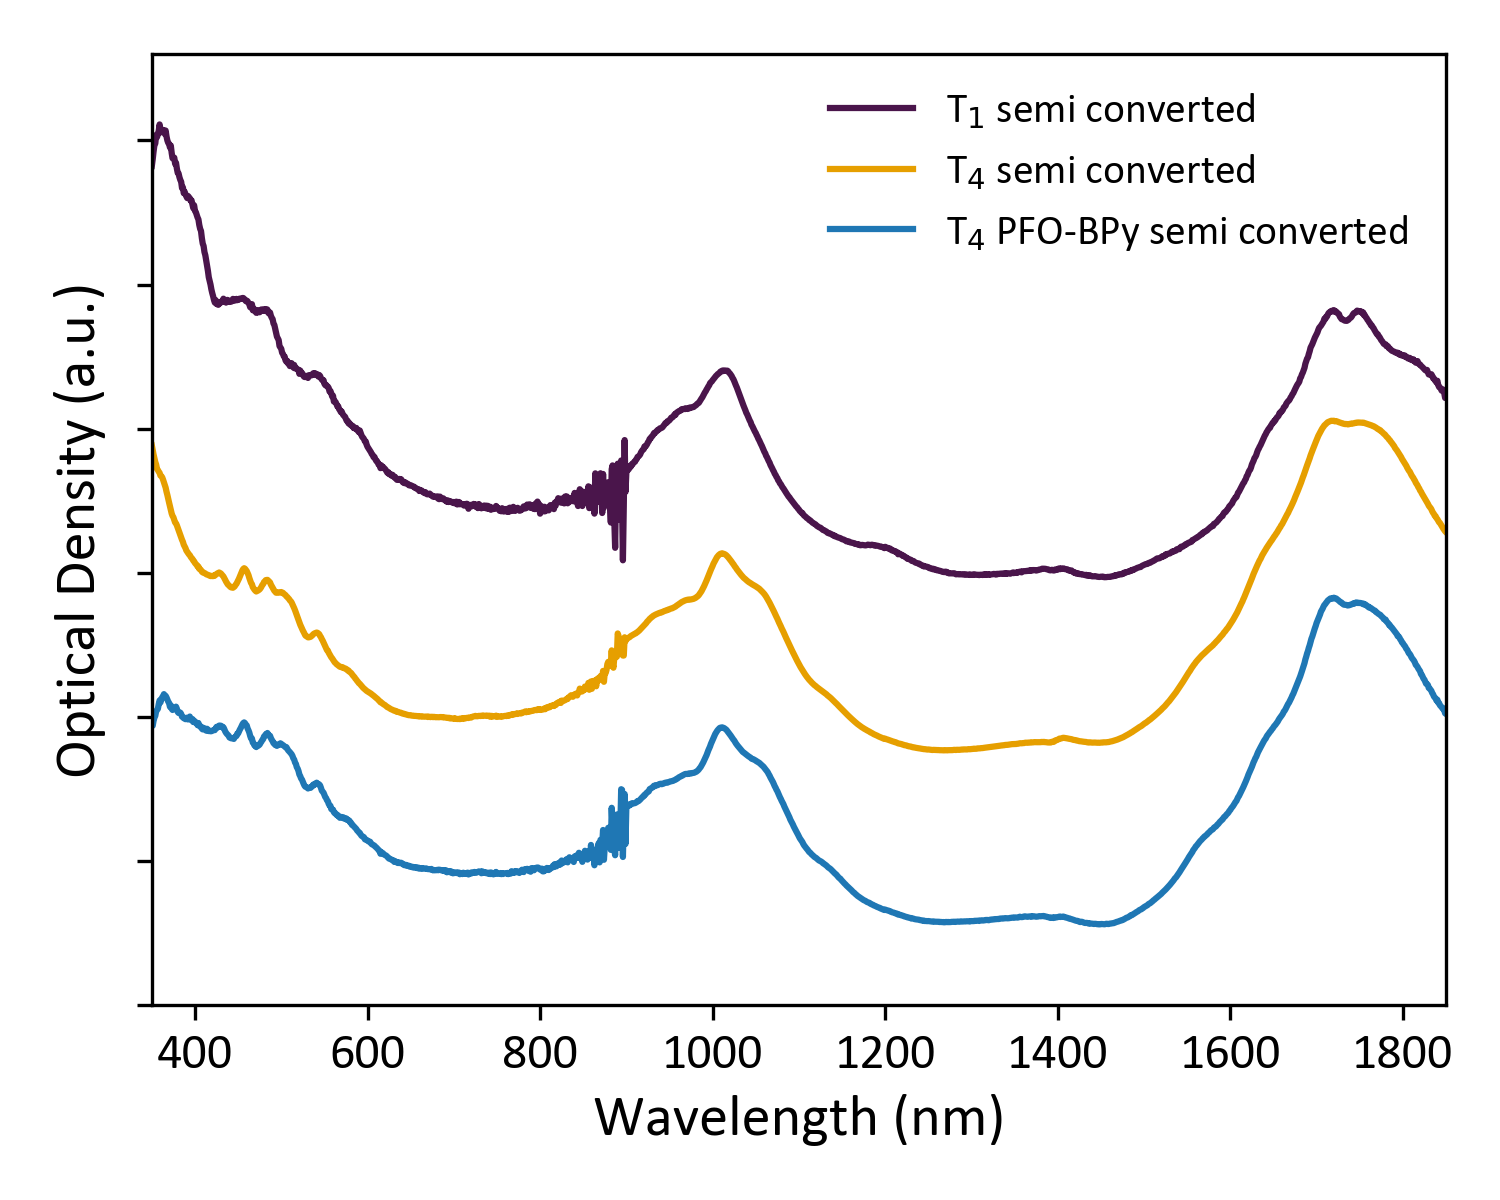

In [252]:
import pandas as pd
# ============================================================
# 3. LOAD DATA & CREATE VARIABLES
# ============================================================
References = r"H:\FUBerlin\Measurements\UVvisNIR\References.csv"
try:
    calibration_df = pd.read_csv(
        References, sep=",", skiprows=2, header=None,
        names=["Water_Wavelength", "WaterInD2O", "Nicodenz_Wavelength", "Nicodenz",
               "Empty_Wavelength", "Empty_P2", "WaterFilled_Wavelength", "WaterFilled"]
    )
    cal_objects = {}
    for i in range(0, len(calibration_df.columns), 2):
        w_col = calibration_df.columns[i]
        a_col = calibration_df.columns[i + 1]
        df_temp = pd.DataFrame({"X": pd.to_numeric(calibration_df[w_col], errors="coerce"),
                                "Y": pd.to_numeric(calibration_df[a_col], errors="coerce")}).dropna().sort_values("X")
        cal_objects[a_col] = Spectrum(N=a_col, X=df_temp["X"].values, Y=df_temp["Y"].values)
    water_calibration = cal_objects["WaterInD2O"]
    nycodenz_calibratopm = cal_objects["WaterInD2O"]

except Exception as e:
    print(f"Warning: Could not load calibration data: {e}")
    



spectra_config = [
    # =========================================================
    # 1. KIT SAMPLES (2024-05-31)
    # =========================================================
     #('20240531_KIT_Samples_T1Converted',     'T1 Converted',      '#0072B2', '-'),
     #('20240531_KIT_Samples_T4Converted',     'T4 Converted',      '#D55E00', '-'),
     #('20240531_KIT_Samples_T4ConvertedPellet','T4 Pellet',        '#CC79A7', '-'),
     #('20240531_KIT_Samples_T4ConvertedPelletB','T4 Pellet B',     '#E69F00', '-'),

    # =========================================================
    # 2. CONVERTED SAMPLES (2024-06-13)
    # =========================================================
     ('20240613_KIT_ConvertedSamples_T1S',            'T$_1$ semi converted',         0.09,  0.05,     '#4A154B', '-',0,0),
     ('20240613_KIT_ConvertedSamples_T4S',            'T$_4$ semi converted',         0.73,  0,      '#E69F00', '-',0,0),
     ('20240613_KIT_ConvertedSamples_T4P',            'T$_4$ PFO-BPy semi converted',         0.243,  0.05,      '#1F77B4', '-',0,0),


     #('20240613_KIT_ConvertedSamples_T1S',            'T1Suncor',         0.0,  0,     '#0060B2', '-',0,0),
     #('20240613_KIT_ConvertedSamples_T4S',            'T4Suncor',         0.0,  0,      '#D56E90', '-',0,0),
     #('20240613_KIT_ConvertedSamples_T4P',            'T4Puncor',         0.0,  0,      '#008E83', '-',0,0),
    # =========================================================
    # 3. FILM CONVERTED SAMPLES (2024-06-14)
    # =========================================================
     #('20240614_KIT_FilmConvertedSamples_FilmT1S',             'Film T1S (SWCNT)', '#0072B2', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT1SConverted',     'Film T1S Conv',    '#0072B2', '--'),
     #('20240614_KIT_FilmConvertedSamples_FilmT2S',             'Film T2S (SWCNT)', '#D55E00', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT2SConverted',     'Film T2S Conv',    '#D55E00', '--'),
     #('20240614_KIT_FilmConvertedSamples_FilmT9M',             'Film T9M (SWCNT)', '#009E73', '-'),
     #('20240614_KIT_FilmConvertedSamples_FilmT9MConverted',     'Film T9M Conv',    '#009E73', '--'),
      
    # =========================================================
    # 5. DIALYSIS & POST-DIAL SAMPLES (2025-03-21)
    # =========================================================
    #('20250321_LastDialisysAndSamplePostDial_DWCNT_Megasonicated_KIT_Dial', 'Megasonicated Dial', '#CC79A7', '-'),
]


Selection = []
for key, name, wcorr, nzcorr,col, ls, a_val, b_val in spectra_config:
    if key in spectra_dict:
        s = spectra_dict[key].copy()
        s.N = name
        s.color = col
        s.linestyle = ls
        s.wcorr = wcorr
        s.nzcorr = nzcorr
        s.a = a_val
        s.b = b_val
        Selection.append(s)
    else:
        print(f"Advertencia: El espectro '{key}' no existe.")



# --- PIPELINE DE PROCESAMIENTO (Opcional) ---
Selection = TrimSpectra(Selection, xmin=350, xmax=1850)
Selection = SubtractMinimum(Selection, xmin=1200, xmax=1300)
Selection = ApplyWaterCorrection(Selection, water_calibration) 
Selection = ApplyNZCorrection(Selection, nycodenz_calibration) 
Selection = NormalizeSpectra(Selection, xmin=900, xmax=1100, mode="I")


poster_style = {
    "figsize": (5, 4),          
    "dpi": 300,                 
    "font_size": 12,
    "title_size": 14,
    "label_size": 14,
    "legend_size": 10,
    "line_width": 1.5,
    "font_family": "Calibri", 
    "grid": False,               
    "colors": ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}



# 3. GRAFICAR
if len(Selection) > 0:
    PlotSpectra(
        spectra_list=Selection,
        mode="W",          # Muestra nm abajo y eV arriba
        style=poster_style,
        title="Absorption Spectra",
        offset_step=-0.006,     # Cambia esto a 0.5 o 1.0 si quieres separar los espectros,
        ymax=0.018,
        ymin=-0.015,
        xmax=1850,
        xmin=350,
        hide_yticks=True,    save_path='CorrectedFigures_Dispersions/Absorption.png'

        
        

    )

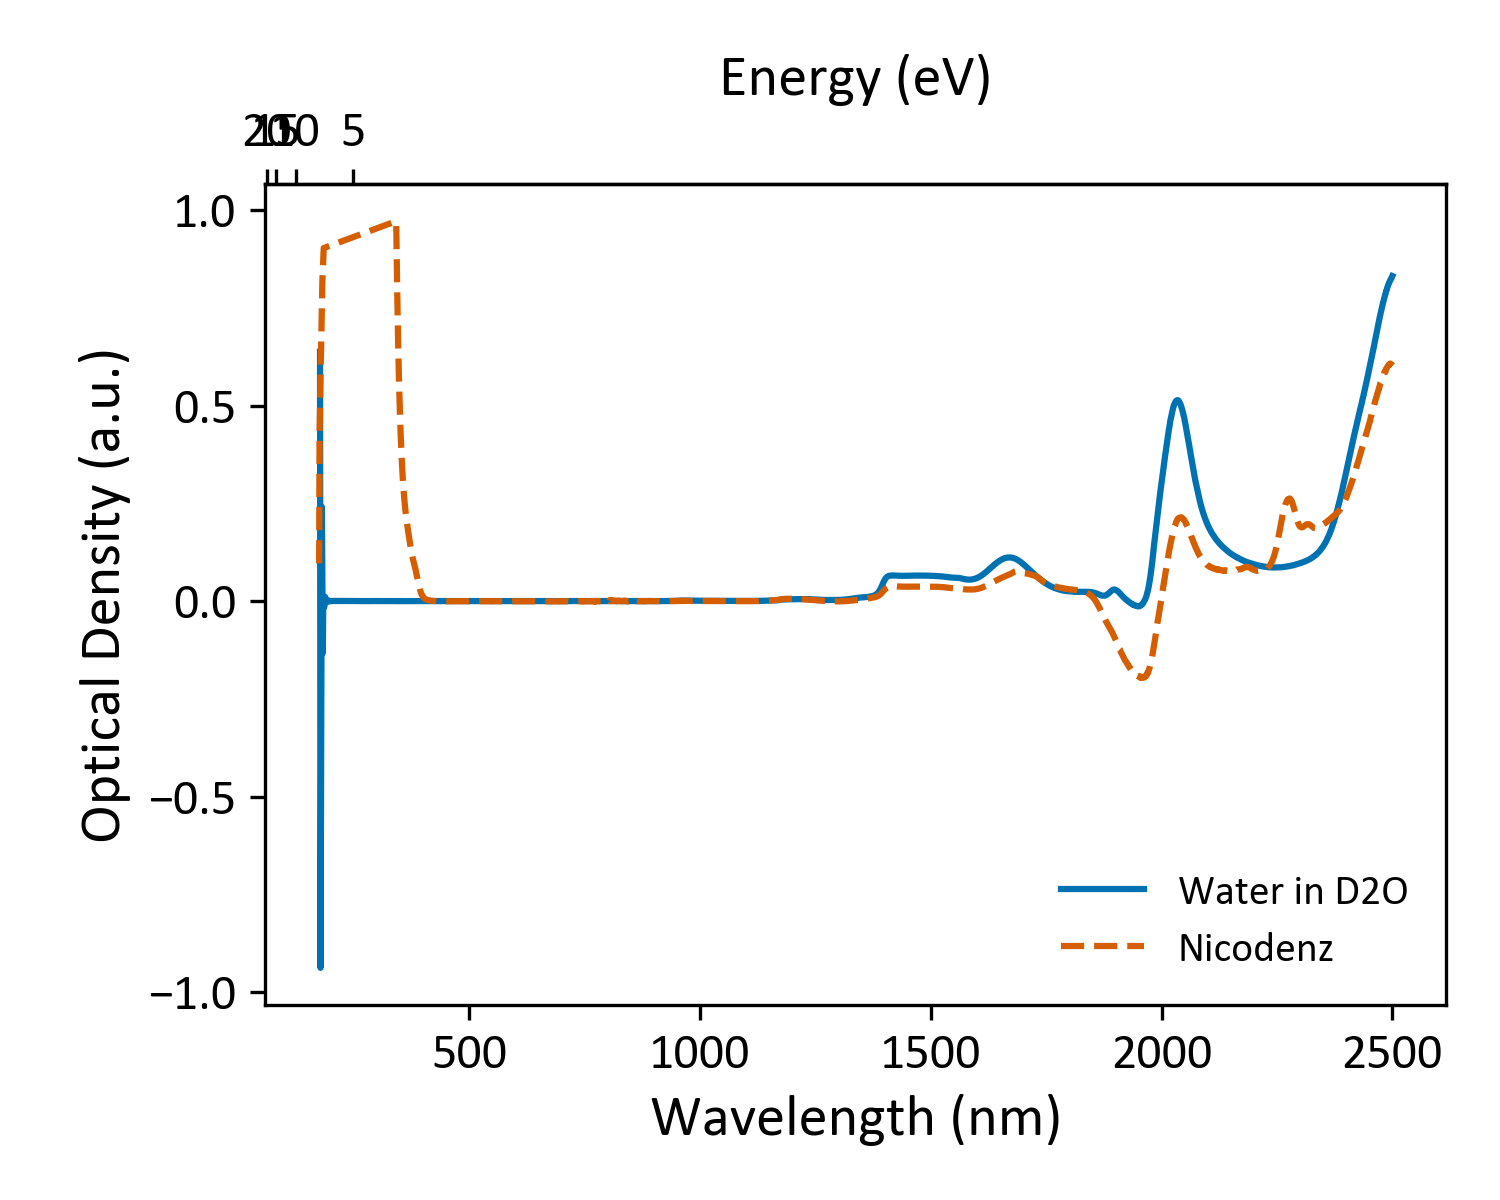

In [251]:
# 1. Seleccionamos las referencias de interés desde cal_objects
refs_to_plot = []

if "WaterInD2O" in cal_objects:
    s_water = cal_objects["WaterInD2O"].copy()
    s_water.N = "Water in D2O"
    s_water.color = "#0072B2"  # Azul
    refs_to_plot.append(s_water)
    
if "Nicodenz" in cal_objects:
    s_nico = cal_objects["Nicodenz"].copy()
    s_nico.N = "Nicodenz"
    s_nico.color = "#D55E00"  # Naranja
    refs_to_plot.append(s_nico)

# 2. Graficar
if len(refs_to_plot) > 0:
    PlotSpectra(
        spectra_list=refs_to_plot,
        mode="WE",              # Muestra Wavelength abajo y Energy arriba
        style=poster_style,
        title="Reference Spectra",
        ylabel="Optical Density (a.u.)",
        offset_step=0.001        # Ponle ej. 0.5 si quieres separarlos verticalmente
    )
else:
    print("Advertencia: No se encontraron las referencias en `cal_objects`. Asegúrate de haber corrido la celda que lee el archivo References.csv.")